In [41]:
# Langkah 3 — Import Library
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Langkah 4 — Membaca File WAV
file_audio = r"E:\Berkas\Semester 9\Aplikasi Pengolahan Sinyal\Music\voice_sample.wav"  # ganti sesuai path file kamu
audio, fs = librosa.load(file_audio, sr=None, mono=True)

print("Sampling Rate :", fs)
print("Jumlah Sample :", len(audio))


Sampling Rate : 44100
Jumlah Sample : 1159830


In [42]:
# Langkah 5 — Menghitung Durasi Audio
N = len(audio)
duration = N / fs
print("Sampling Rate :", fs, "Hz")
print("Jumlah Sample :", N)
print("Durasi Audio  :", duration, "detik")

Sampling Rate : 44100 Hz
Jumlah Sample : 1159830
Durasi Audio  : 26.3 detik


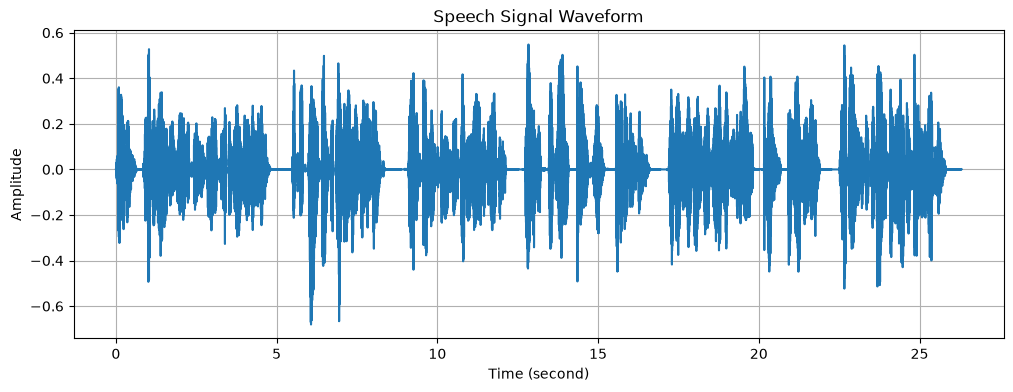

In [43]:
# Langkah 6 — Membuat Time Axis
time = np.arange(N) / fs

# Langkah 7 — Menampilkan Waveform
plt.figure(figsize=(12, 4))
plt.plot(time, audio)
plt.title("Speech Signal Waveform")
plt.xlabel("Time (second)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Amplitude maksimum : 0.5481262
Amplitude minimum : -0.68066406


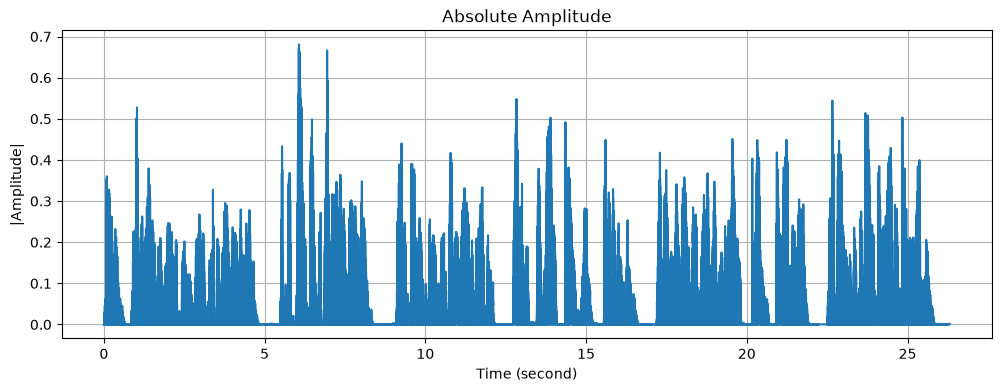

In [44]:
# Langkah 8 — Analisis Amplitude
amp_max = np.max(audio)
amp_min = np.min(audio)
print("Amplitude maksimum :", amp_max)
print("Amplitude minimum :", amp_min)

amplitude = np.abs(audio)
plt.figure(figsize=(12, 4))
plt.plot(time, amplitude)
plt.title("Absolute Amplitude")
plt.xlabel("Time (second)")
plt.ylabel("|Amplitude|")
plt.grid()
plt.show()

Frame length : 1102
Hop length   : 441


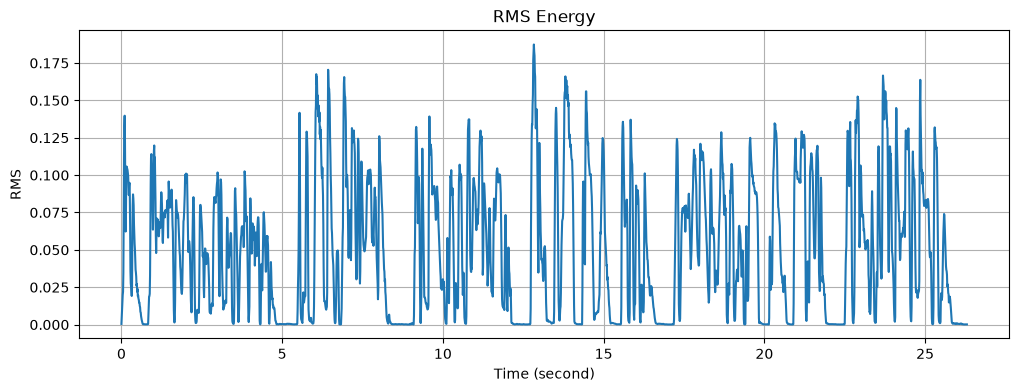

In [45]:
# Langkah 9 — Membagi Speech Menjadi Frame
frame_length = int(0.025 * fs)  # 25 ms
hop_length = int(0.010 * fs)    # 10 ms
print("Frame length :", frame_length)
print("Hop length   :", hop_length)

# Langkah 10 — Menghitung RMS Energy
rms = librosa.feature.rms(
    y=audio,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

rms_time = librosa.frames_to_time(
    np.arange(len(rms)),
    sr=fs,
    hop_length=hop_length
)

plt.figure(figsize=(12, 4))
plt.plot(rms_time, rms)
plt.title("RMS Energy")
plt.xlabel("Time (second)")
plt.ylabel("RMS")
plt.grid()
plt.show()

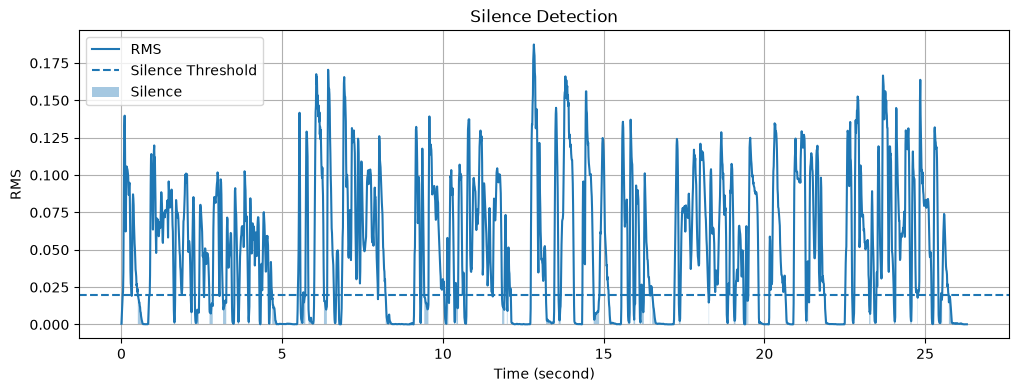

In [46]:
# Langkah 11 — Deteksi Silence
silence_threshold = 0.02  # sesuaikan dengan karakteristik audio kamu
silence = rms < silence_threshold

plt.figure(figsize=(12, 4))
plt.plot(rms_time, rms, label="RMS")
plt.axhline(silence_threshold, linestyle="--", label="Silence Threshold")
plt.fill_between(rms_time, 0, rms, where=silence, alpha=0.4, label="Silence")
plt.title("Silence Detection")
plt.xlabel("Time (second)")
plt.ylabel("RMS")
plt.legend()
plt.grid()
plt.show()

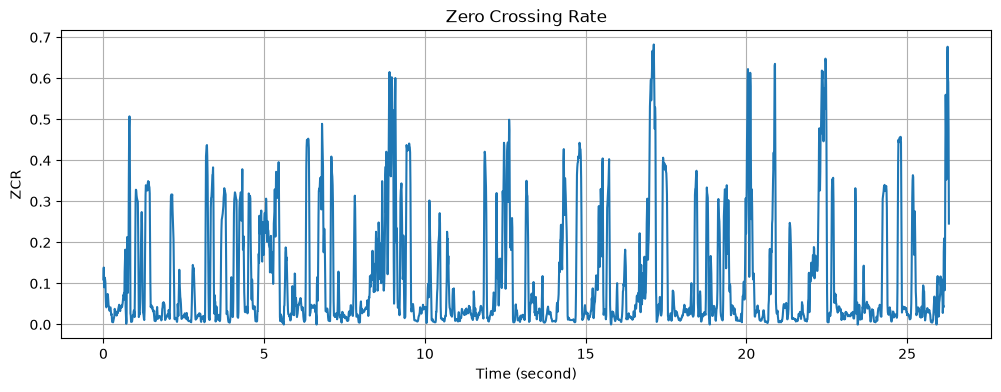

In [47]:
# Langkah 12 — Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(
    audio,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

plt.figure(figsize=(12, 4))
plt.plot(rms_time, zcr)
plt.title("Zero Crossing Rate")
plt.xlabel("Time (second)")
plt.ylabel("ZCR")
plt.grid()
plt.show()

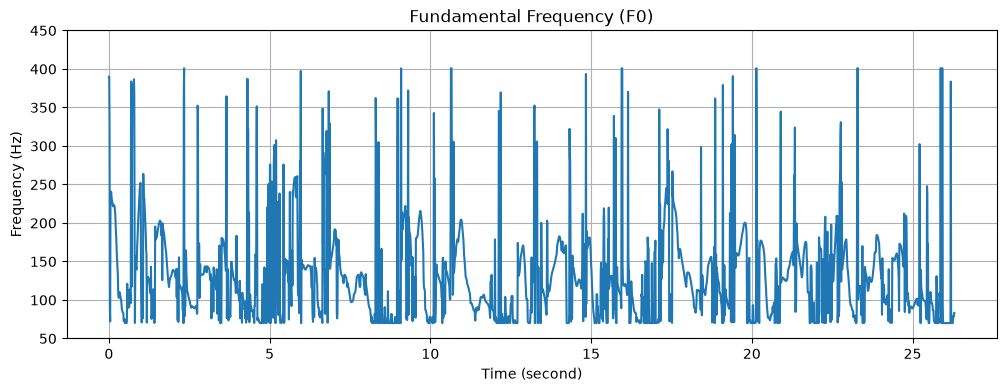

In [48]:
# Langkah 13 — Analisis Pitch/F0 (algoritma YIN)
f0 = librosa.yin(
    audio,
    fmin=70,
    fmax=400,
    sr=fs,
    frame_length=frame_length * 2,
    hop_length=hop_length
)

pitch_time = librosa.times_like(f0, sr=fs, hop_length=hop_length)

plt.figure(figsize=(12, 4))
plt.plot(pitch_time, f0)
plt.title("Fundamental Frequency (F0)")
plt.xlabel("Time (second)")
plt.ylabel("Frequency (Hz)")
plt.ylim(50, 450)
plt.grid()
plt.show()

In [49]:
# Langkah 15-17 — Menentukan Voiced, Unvoiced, Silence
energy_threshold = np.percentile(rms, 20)

voiced = (rms[:len(f0)] > energy_threshold) & np.isfinite(f0)
unvoiced = (rms[:len(f0)] > energy_threshold) & (~np.isfinite(f0))
silence = rms[:len(f0)] <= energy_threshold

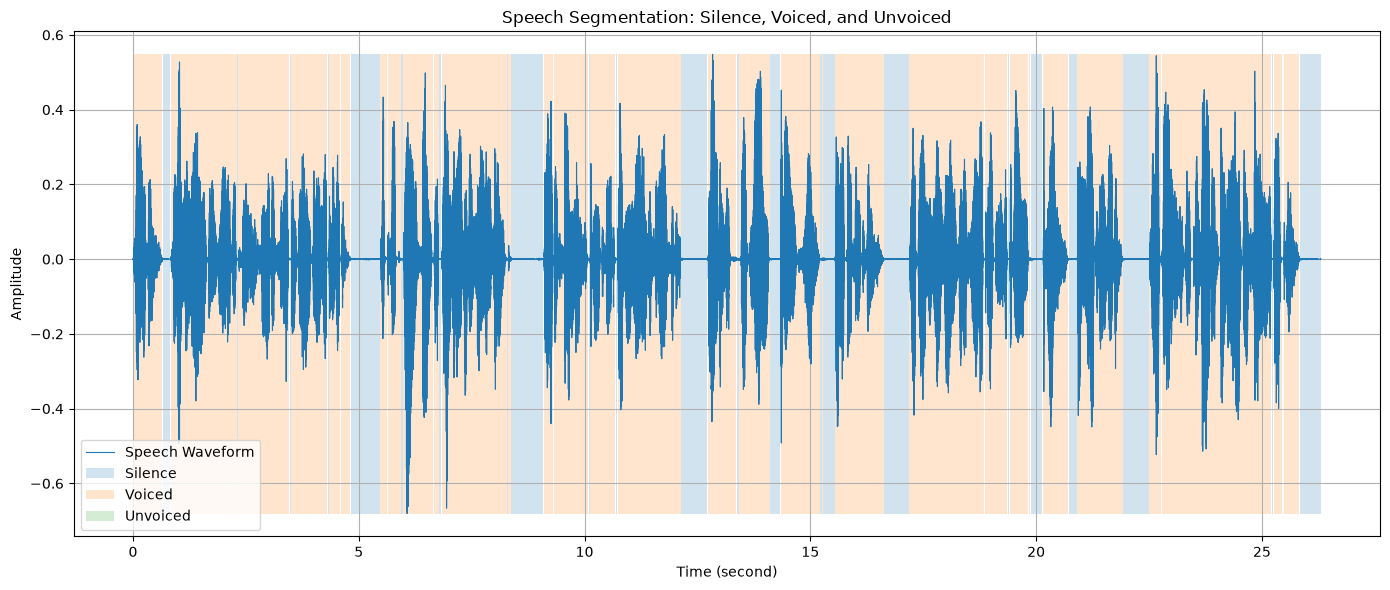

In [50]:
# Langkah 18 — Visualisasi Silence, Voiced, Unvoiced
plt.figure(figsize=(14, 6))
plt.plot(time, audio, linewidth=0.8, label="Speech Waveform")

plt.fill_between(pitch_time, np.min(audio), np.max(audio), where=silence, alpha=0.2, label="Silence")
plt.fill_between(pitch_time, np.min(audio), np.max(audio), where=voiced, alpha=0.2, label="Voiced")
plt.fill_between(pitch_time, np.min(audio), np.max(audio), where=unvoiced, alpha=0.2, label="Unvoiced")

plt.title("Speech Segmentation: Silence, Voiced, and Unvoiced")
plt.xlabel("Time (second)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [51]:
# Langkah 19 — Menghitung Persentase Setiap Segment
total_frames = len(f0)
n_silence = np.sum(silence)
n_voiced = np.sum(voiced)
n_unvoiced = np.sum(unvoiced)

percentage_silence = n_silence / total_frames * 100
percentage_voiced = n_voiced / total_frames * 100
percentage_unvoiced = n_unvoiced / total_frames * 100

print("====================================")
print("HASIL SEGMENTASI")
print("====================================")
print(f"Silence   : {percentage_silence:.2f}%")
print(f"Voiced    : {percentage_voiced:.2f}%")
print(f"Unvoiced  : {percentage_unvoiced:.2f}%")

HASIL SEGMENTASI
Silence   : 20.03%
Voiced    : 79.97%
Unvoiced  : 0.00%
